Digite o Produto Desejado: Notebook


 
Descontos Disponíveis: Mais de 5% OFF
Descontos Disponíveis: Mais de 10% OFF
Descontos Disponíveis: Mais de 15% OFF
Descontos Disponíveis: Mais de 20% OFF
Descontos Disponíveis: Mais de 25% OFF
Descontos Disponíveis: Mais de 30% OFF
Descontos Disponíveis: Mais de 40% OFF
 


Defina qual dos descontos será utilizado na pesquisa:  Mais de 15% OFF


 
Item 1 - Produto: Notebook Dell Vostro 3401 I5 10ª Ger 16gb M2 256gb +hd 500gb, Preço: R$ 2.263, Qualidade: 0, Críticas 0 
Item 2 - Produto: Kit Escova Limpeza Notebook Celular Teclado Fone Pc 7 Em 1, Preço: R$ 26, Qualidade: 4.8, Críticas (190) 
Item 3 - Produto: Notebook Core I5 256gb 16gb Ddr4 Ssd M2 Usb-c Usb 3.0 5490, Preço: R$ 2.541, Qualidade: 5.0, Críticas (3) 
Item 4 - Produto: Notebook Lenovo Ideapad 1i I5-1235u 8gb Ram 512gb 15,6 W11, Preço: R$ 2.899, Qualidade: 5.0, Críticas (6) 
Item 5 - Produto: Notebook Intel Core I5 Acer Aspire 5 8gb Ram 256gb Tela 15'6, Preço: R$ 2.777, Qualidade: 0, Críticas 0 
Item 6 - Produto: Notebook Positivo Vision C15 Lumina Bar Intel 4gb 128gb Hdd, Preço: R$ 1.386, Qualidade: 0, Críticas 0 
Item 7 - Produto: Notebook Gamer Acer Nitro 5 15.6 Fhd 144hz I5 Ssd 512gb 8gb, Preço: R$ 4.599, Qualidade: 0, Críticas 0 
Item 8 - Produto: Notebook Acer Aspire 5 A515-57-57t3 I5 W11 8gb 512gb 15,6', Preço: R$ 2.999, Qualidade: 4.8, Críticas (25) 
Item 9 -

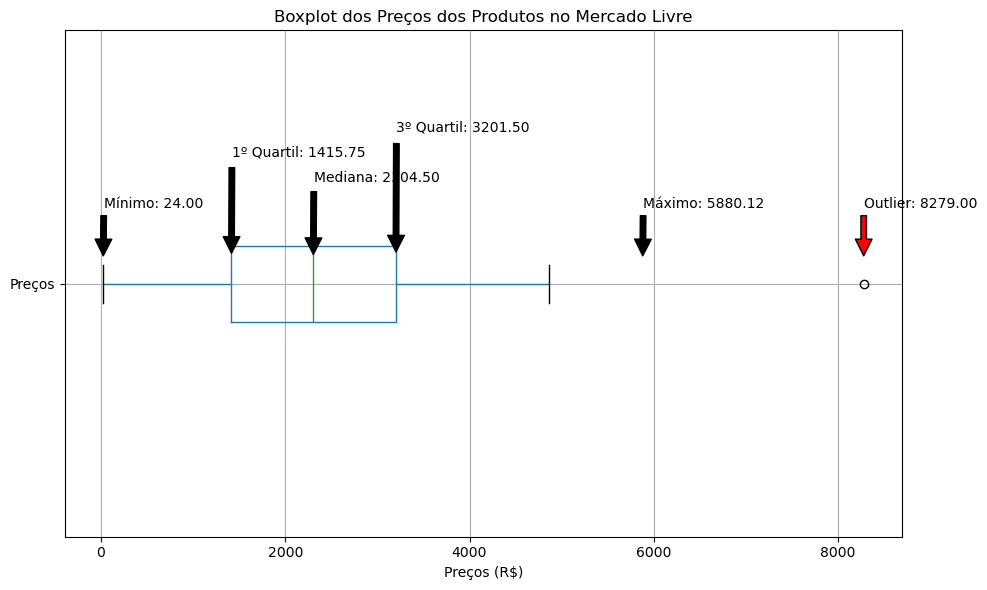

In [38]:
# Blibiotecas 
from selenium import webdriver
from selenium.webdriver.common.keys import Keys
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from selenium.webdriver.chrome.options import Options
import pandas as pd
import openpyxl
from openpyxl.chart import BarChart, Reference
from openpyxl.utils.dataframe import dataframe_to_rows
import matplotlib.pyplot as plt 


# Configurar opções do Chrome
chrome_options = Options()
chrome_options.add_argument("user-agent=Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/90.0.4430.93 Safari/537.36")

# Iniciar o Chrome com as opções configuradas
chrome = webdriver.Chrome(options=chrome_options)

# Abrir Mercado Livre
chrome.get("https://www.mercadolivre.com.br")

# Procurar campo de busca pelo id e atribuir item de pesquisa
campo_pesquisa = chrome.find_element(By.ID, "cb1-edit")
campo_pesquisa.send_keys( input('Digite o Produto Desejado:'))
campo_pesquisa.send_keys(Keys.RETURN)

print(' ')

# função de espera
wait = WebDriverWait(chrome, 10)

# Esperar carregar os filtros na barra lateral
wait.until(EC.visibility_of_element_located((By.CLASS_NAME, "ui-search-sidebar")))

# definir a barra lateral
barra_lateral = chrome.find_elements(By.CLASS_NAME, "ui-search-sidebar")

# Iterar sobre cada elemento da barra lateral
for barra in barra_lateral:
    # Encontrar as opções de desconto dentro da barra lateral atual
    opcoes_desconto = barra.find_elements(By.XPATH, "//span[contains(text(), 'Mais de ') and contains(text(), '%')]")
    
    # Verificar se há opções de desconto encontradas
    if opcoes_desconto:
        for opcao in opcoes_desconto:
            desconto = opcao.text
            print(f"Descontos Disponíveis: {desconto}")
    else:
        print("Nenhum desconto encontrado nesta barra lateral.")

print(' ')

# NÃO ACEITAR O COOKIE TAVA DANDO ERRO
aceitar_cookie = chrome.find_element(By.XPATH, "/html/body/div[2]/div[1]/div/div[2]/button[1]")
aceitar_cookie.click()

escolha = input('Defina qual dos descontos será utilizado na pesquisa: ')

# Encontrar o elemento de link correspondente ao desconto escolhido
elemento_escolhido = barra.find_element(By.XPATH, f"//a[contains(@title, '{escolha}')]")

# Clicar no elemento
elemento_escolhido.click()

# Esperar estar visivel o titulo dos produtos e os preços
wait.until(EC.visibility_of_element_located((By.CLASS_NAME, "ui-search-item__title")))
wait.until(EC.visibility_of_element_located((By.CSS_SELECTOR, ".andes-money-amount.ui-search-price__part.ui-search-price__part--medium.andes-money-amount--cents-superscript .andes-money-amount__fraction")))

# Obter e imprimir os títulos dos produtos encontrados
produtos = chrome.find_elements(By.CLASS_NAME, "ui-search-item__title")
precos = chrome.find_elements(By.CSS_SELECTOR, ".andes-money-amount.ui-search-price__part.ui-search-price__part--medium.andes-money-amount--cents-superscript .andes-money-amount__fraction")
cartoes = chrome.find_elements(By.CLASS_NAME, "ui-search-result__content-wrapper") 
#qualidades = chrome.find_elements(By.CLASS_NAME, "ui-search-reviews__rating-number")
#criticas = chrome.find_elements(By.CLASS_NAME, "ui-search-reviews__amount") 

lista_produto= []
lista_preco= []
lista_qualidade= []
lista_critica= []

for i, produto in enumerate (produtos, 1):
    lista_produto.append(produto.text)
    #print(f" Produto {i}: {produto.text}")

for i, preco in enumerate (precos, 1):
    lista_preco.append(preco.text)
    #print(f" Preço {i}: {preco.text}")

for i, cartao in enumerate(cartoes, 1):
    qualidades = cartao.find_elements(By.CLASS_NAME, "ui-search-reviews__rating-number")
    qualidade_valor = qualidades[0].text if qualidades else "0"
    lista_qualidade.append(qualidade_valor)
    #print(f"Qualidade {i}: {qualidade_valor}")

for i, cartao in enumerate(cartoes, 1):
    criticas = cartao.find_elements(By.CLASS_NAME, "ui-search-reviews__amount")
    critica_valor = criticas[0].text if criticas else "0"
    lista_critica.append(critica_valor)
    #print(f"Crítica {i}: {critica_valor}")

print(' ')

if len(lista_produto) == len(lista_preco) == len(lista_qualidade) == len(lista_critica):
    #Combine os produtos e preços em uma lista de tuplas
    lista_combinada = [(lista_produto[i], lista_preco[i], lista_qualidade[i], lista_critica[i]) for i in range(len(lista_produto))]
    
    #Imprima a lista combinada
    for i, (produto, preco, qualidade, critica) in enumerate(lista_combinada, 1):
        print(f"Item {i} - Produto: {produto}, Preço: R$ {preco}, Qualidade: {qualidade}, Críticas {critica} ")
else:
    print("As listas de preços e produtos não têm o mesmo comprimento.")

# Encerrar o processo
chrome.quit()

print('=-='*76)
print(" ")

# Supondo que df é o seu DataFrame
# df = ...  # Seu código existente deve criar o dataframe 'df'

lista_produto = lista_produto[:54]
lista_preco = lista_preco[:54]
lista_qualidade = lista_qualidade[:54]
lista_critica = lista_critica[:54]

df = pd.DataFrame({
    "Produtos": lista_produto,
    "Preços": lista_preco,
    "Qualidade": lista_qualidade,
    "Críticas": lista_critica
})
df.index+= 1
df= df.sort_values("Produtos")
df

# Salvar o DataFrame em um arquivo CSV
csv_path = 'C:/Users/rafae/Downloads/A3 - Análise de Dados e Big Data/arquivo certo/produtos.csv'
df.to_csv(csv_path, index=False)
print(f"DataFrame salvo em CSV: {csv_path}")

# Criar um workbook e adicionar uma planilha
wb = openpyxl.Workbook()
ws = wb.active
ws.title = "Dados de Produtos"

# Adicionar dados do dataframe à planilha
for r in dataframe_to_rows(df, index=False, header=True):
    ws.append(r)

# Salvar o workbook como arquivo Excel
excel_path = 'C:/Users/rafae/Downloads/A3 - Análise de Dados e Big Data/arquivo certo/produtos_com_graficos.xlsx'
wb.save(excel_path)
print(f"Arquivo Excel salvo: {excel_path}")

# Função para converter os valores
def converter_lista(lista):
    # Remove o ponto e converte para inteiro
    return [int(valor.replace('.', '')) for valor in lista]

# Converte a lista
lista_convertida = converter_lista(lista_preco)

#Dados Convertidos para analise no boxplot:

df = pd.DataFrame({
    "Preços": lista_convertida
})

df

def criar_boxplot(df, coluna, titulo, rotulo_eixo_x):
    plt.figure(figsize=(10, 6))  # Define o tamanho da figura
    boxplot = df.boxplot(column=coluna, vert=False)  # Cria o boxplot

    # Adicionar anotações
    plt.title(titulo)  # Título do gráfico
    plt.xlabel(rotulo_eixo_x)  # Rótulo do eixo x

    # Calcular estatísticas
    stats = df[coluna].describe()
    iqr = stats['75%'] - stats['25%']
    lower_whisker = max(stats['min'], stats['25%'] - 1.5 * iqr)
    upper_whisker = min(stats['max'], stats['75%'] + 1.5 * iqr)
    outliers = df[(df[coluna] < lower_whisker) | (df[coluna] > upper_whisker)]

    # Anotações
    plt.annotate(f'Mediana: {stats["50%"]:.2f}', xy=(stats['50%'], 1.05), xytext=(stats['50%']+5, 1.2),
                             arrowprops=dict(facecolor='black', shrink=0.05))
    plt.annotate(f'1º Quartil: {stats["25%"]:.2f}', xy=(stats['25%'], 1.05), xytext=(stats['25%']+5, 1.25),
                             arrowprops=dict(facecolor='black', shrink=0.05))
    plt.annotate(f'3º Quartil: {stats["75%"]:.2f}', xy=(stats['75%'], 1.05), xytext=(stats['75%']+5, 1.3),
                             arrowprops=dict(facecolor='black', shrink=0.05))
    plt.annotate(f'Mínimo: {lower_whisker:.2f}', xy=(lower_whisker, 1.05), xytext=(lower_whisker+5, 1.15),
                             arrowprops=dict(facecolor='black', shrink=0.05))
    plt.annotate(f'Máximo: {upper_whisker:.2f}', xy=(upper_whisker, 1.05), xytext=(upper_whisker+5, 1.15),
                             arrowprops=dict(facecolor='black', shrink=0.05))
    
    # Anotação para outliers
    for outlier in outliers[coluna]:
                    plt.annotate(f'Outlier: {outlier:.2f}', xy=(outlier, 1.05), xytext=(outlier, 1.15),
                                 arrowprops=dict(facecolor='red', shrink=0.05))
    
    # Adicionar grade ao gráfico
    plt.grid(True)
    
    # Ajustar layout
    plt.tight_layout()
    
    # Exibir o gráfico
    plt.show()

# Gerar o Boxplot para Preços
criar_boxplot(df, 'Preços', 'Boxplot dos Preços dos Produtos no Mercado Livre', 'Preços (R$)')